In [2]:
import pandas as pd

df = pd.read_csv("data/mutual_fund_data.csv")

print(df.shape)
df.head()

(16383, 16)


,Scheme_Code,Scheme_Name,AMC,Scheme_Type,Scheme_Category,Scheme_NAV_Name,Scheme_Min_Amt,NAV,Latest_NAV_Date,Average_AUM_Cr,AAUM_Quarter,ISIN_Div_Payout/Growth,ISIN_Div_Reinvestment,ISIN_Div_Payout/Growth/Div_Reinvestment,Launch_Date,Closure_Date
0,100033,Aditya Birla Sun Life Large & Mid Cap Fund,Aditya Birla Sun Life AMC Limited,Open Ended,Equity Scheme - Large & Mid Cap Fund,Aditya Birla Sun Life Large & Mid Cap Fund - R...,5000,893.5100,2026-05-20,4428.2119,January - March 2026,INF209K01165,-,INF209K01165,1995-02-24,1995-02-24
1,100034,Aditya Birla Sun Life Large & Mid Cap Fund,Aditya Birla Sun Life AMC Limited,Open Ended,Equity Scheme - Large & Mid Cap Fund,Aditya Birla Sun Life Large & Mid Cap Fund -Re...,5000,130.1300,2026-05-20,457.6450,January - March 2026,INF209K01157,INF209K01CE5,INF209K01157INF209K01CE5,1995-02-24,1995-02-24
2,100037,Aditya Birla Sun Life Income Fund,Aditya Birla Sun Life AMC Limited,Open Ended,Debt Scheme - Medium to Long Duration Fund,Aditya Birla Sun Life Income Fund - Regular - ...,5000,12.8569,2026-05-20,11.1344,January - March 2026,INF209K01587,INF209K01CY3,INF209K01587INF209K01CY3,1994-01-01,1994-01-01
3,100038,Aditya Birla Sun Life Income Fund,Aditya Birla Sun Life AMC Limited,Open Ended,Debt Scheme - Medium to Long Duration Fund,Aditya Birla Sun Life Income Fund - Growth - R...,5000,126.1951,2026-05-20,780.1475,January - March 2026,INF209K01579,-,INF209K01579,1994-01-01,1994-01-01
4,100039,Aditya Birla Sun Life Income Fund,Aditya Birla Sun Life AMC Limited,Open Ended,Debt Scheme - Medium to Long Duration Fund,Birla Income Plus-Institutional (Growth),5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1994-01-01,1994-01-01


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16383 entries, 0 to 16382
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Scheme_Code                              16383 non-null  int64  
 1   Scheme_Name                              16383 non-null  object 
 2   AMC                                      16383 non-null  object 
 3   Scheme_Type                              16383 non-null  object 
 4   Scheme_Category                          16383 non-null  object 
 5   Scheme_NAV_Name                          16383 non-null  object 
 6   Scheme_Min_Amt                           16353 non-null  object 
 7   NAV                                      14367 non-null  float64
 8   Latest_NAV_Date                          14367 non-null  object 
 9   Average_AUM_Cr                           8216 non-null   float64
 10  AAUM_Quarter                             8216 

In [4]:
# How many funds have AUM data?
active = df[df["Average_AUM_Cr"].notna()]
print(f"Total funds: {len(df)}")
print(f"Funds with AUM data: {len(active)}")

# What Scheme_Types do they belong to?
print("\nScheme_Type breakdown:")
print(active["Scheme_Type"].value_counts())

Total funds: 16383
Funds with AUM data: 8216

Scheme_Type breakdown:
Scheme_Type
Open Ended       7827
Close Ended       380
Interval Fund       9
Name: count, dtype: int64


In [5]:
print(f"Unique categories: {df['Scheme_Category'].nunique()}")
print()
print(df["Scheme_Category"].value_counts())

Unique categories: 50

Scheme_Category
Income                                                            6277
Other Scheme - Index Funds                                        1329
Equity Scheme - Sectoral/ Thematic                                1035
Other Scheme - FoF Domestic                                        559
Debt Scheme - Liquid Fund                                          529
Growth                                                             357
Debt Scheme - Overnight Fund                                       315
Other Scheme - Other  ETFs                                         312
Debt Scheme - Ultra Short Duration Fund                            309
Debt Scheme - Short Duration Fund                                  293
Debt Scheme - Low Duration Fund                                    285
Debt Scheme - Money Market Fund                                    249
Debt Scheme - Corporate Bond Fund                                  237
Debt Scheme - Dynamic Bond            

In [6]:
def categorize(cat):
    cat = str(cat)
    if cat.startswith("Equity") or cat in ["Growth", "ELSS"]:
        return "Equity"
    elif cat.startswith("Debt") or cat in ["Income", "Liquid", "Gilt", "Money Market", "Assured Return"]:
        return "Debt"
    elif cat.startswith("Hybrid") or cat == "Balanced":
        return "Hybrid"
    elif cat.startswith("Other"):
        return "Other / Index & ETF"
    elif cat.startswith("Solution"):
        return "Solution Oriented"
    else:
        return "Uncategorized"

df["Broad_Category"] = df["Scheme_Category"].apply(categorize)

print(df["Broad_Category"].value_counts())

Broad_Category
Debt                   9914
Equity                 2863
Other / Index & ETF    2420
Hybrid                 1038
Solution Oriented       148
Name: count, dtype: int64


In [7]:
# Work only with active funds (those with AUM data)
active = df[df["Average_AUM_Cr"].notna()].copy()

total_funds = len(active)
total_amcs = active["AMC"].nunique()
total_aum = active["Average_AUM_Cr"].sum()

print(f"Total Active Funds : {total_funds:,}")
print(f"Total AMCs         : {total_amcs}")
print(f"Total AUM          : ₹{total_aum:,.0f} Cr")

Total Active Funds : 8,216
Total AMCs         : 47
Total AUM          : ₹8,285,699 Cr


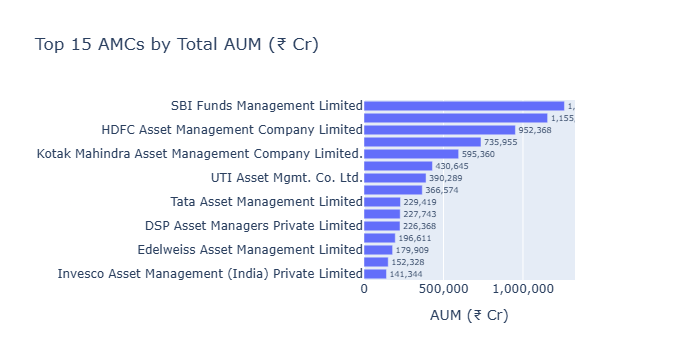

In [9]:
import plotly.express as px

# Group by AMC and sum AUM, then sort
amc_aum = (active.groupby("AMC")["Average_AUM_Cr"]
           .sum()
           .reset_index()
           .sort_values("Average_AUM_Cr", ascending=False)
           .head(15))  # Top 15 only, otherwise chart gets crowded

# Round for cleaner display
amc_aum["Average_AUM_Cr"] = amc_aum["Average_AUM_Cr"].round(0)

fig = px.bar(
    amc_aum,
    x="Average_AUM_Cr",
    y="AMC",
    orientation="h",                        # horizontal bar
    title="Top 15 AMCs by Total AUM (₹ Cr)",
    labels={"Average_AUM_Cr": "AUM (₹ Cr)", "AMC": ""},
    text="Average_AUM_Cr",                  # show value on each bar
)

fig.update_traces(texttemplate="%{text:,.0f}", textposition="outside")
fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    xaxis={"tickformat": ","},       # removes the M suffix, shows plain numbers
    margin={"r": 120}                # adds right margin so labels don't get cut off
)
fig.show()

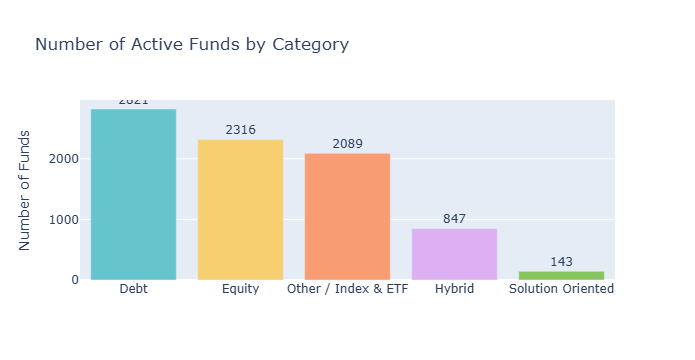

In [10]:
# Count funds per broad category
category_counts = (active.groupby("Broad_Category")["Scheme_Code"]
                   .count()
                   .reset_index()
                   .rename(columns={"Scheme_Code": "Fund_Count"})
                   .sort_values("Fund_Count", ascending=False))

fig2 = px.bar(
    category_counts,
    x="Broad_Category",
    y="Fund_Count",
    title="Number of Active Funds by Category",
    labels={"Broad_Category": "", "Fund_Count": "Number of Funds"},
    text="Fund_Count",
    color="Broad_Category",         # different color per bar
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig2.update_traces(textposition="outside")
fig2.update_layout(showlegend=False)  # legend is redundant since x-axis already labels it
fig2.show()

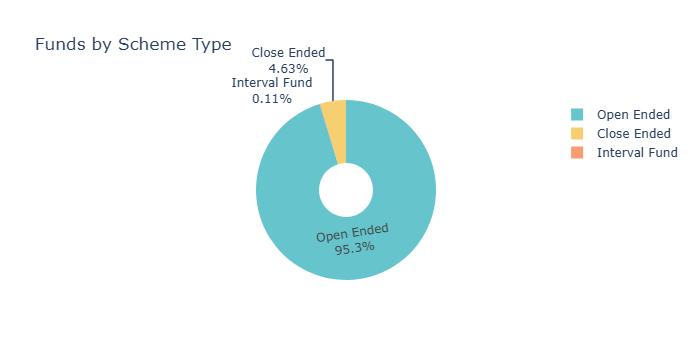

In [12]:
scheme_type_counts = (active.groupby("Scheme_Type")["Scheme_Code"]
                      .count()
                      .reset_index()
                      .rename(columns={"Scheme_Code": "Fund_Count"}))

fig3 = px.pie(
    scheme_type_counts,
    names="Scheme_Type",
    values="Fund_Count",
    title="Funds by Scheme Type",
    hole=0.30,                          # makes it a donut instead of a full pie
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig3.update_traces(textinfo="percent+label")
fig3.show()

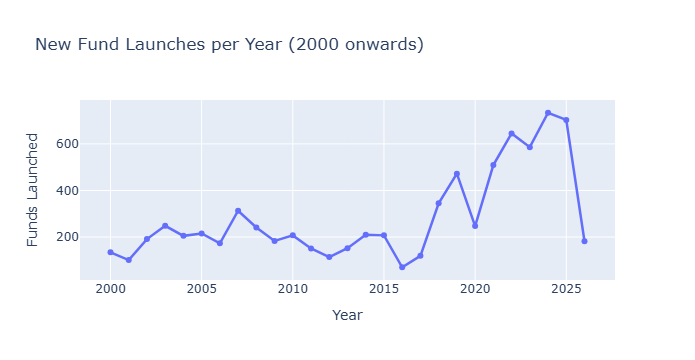

In [13]:
# Convert Launch_Date to datetime, extract year
active["Launch_Date"] = pd.to_datetime(active["Launch_Date"], errors="coerce")
active["Launch_Year"] = active["Launch_Date"].dt.year

# Count funds launched per year, filter out very old/null years
launches = (active.groupby("Launch_Year")["Scheme_Code"]
            .count()
            .reset_index()
            .rename(columns={"Scheme_Code": "Funds_Launched"}))

launches = launches[launches["Launch_Year"] >= 2000]   # 2000 onwards is meaningful

fig4 = px.line(
    launches,
    x="Launch_Year",
    y="Funds_Launched",
    title="New Fund Launches per Year (2000 onwards)",
    labels={"Launch_Year": "Year", "Funds_Launched": "Funds Launched"},
    markers=True                        # shows a dot at each data point
)

fig4.update_traces(line_color="#636EFA", line_width=2.5)
fig4.show()

## 📊 Key Findings — India Mutual Funds

---

| # | Finding | Value |
|---|---------|-------|
| 🏆 | **Largest AMC** | SBI Funds Management Ltd. |
| 📂 | **Most Funds In** | Debt — 2,821 active funds |
| 💰 | **Average Fund Size** | ₹1,009 Cr |
| 📈 | **Peak Launch Year** | 2024 — 706 funds launched |
| 🔓 | **Open Ended Share** | 95.3% of all active funds |

---

> *Based on 8,216 active funds across 47 AMCs with a combined AUM of ₹82.9L Cr (Jan–Mar 2026)*